In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [16]:
with open('configs/50kSteps_a_2.pkl', 'rb') as f:
    temp = pickle.load(f)

In [17]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.2
2
8
16
2.5
50000


In [18]:
bIn = 500
skp = 25

thetas = np.linspace(0,np.pi,20)

correls = []
masses = []

for t in thetas:
    c = sim.distillation.correlStats(temp,burnIn=bIn,autocorrSkip=skp,theta=t)
    correls.append(c)
    masses.append(sim.distillation.correlMassExtract(c,fitT=[3,11],diagCov=True))

masses=np.array(masses)

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

...

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

configs:   0%|          | 0/1980 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Correlation: $N_t = 16$, $N_x=8$, $a=2$, $m=0.2$, $\\beta=2.5$')

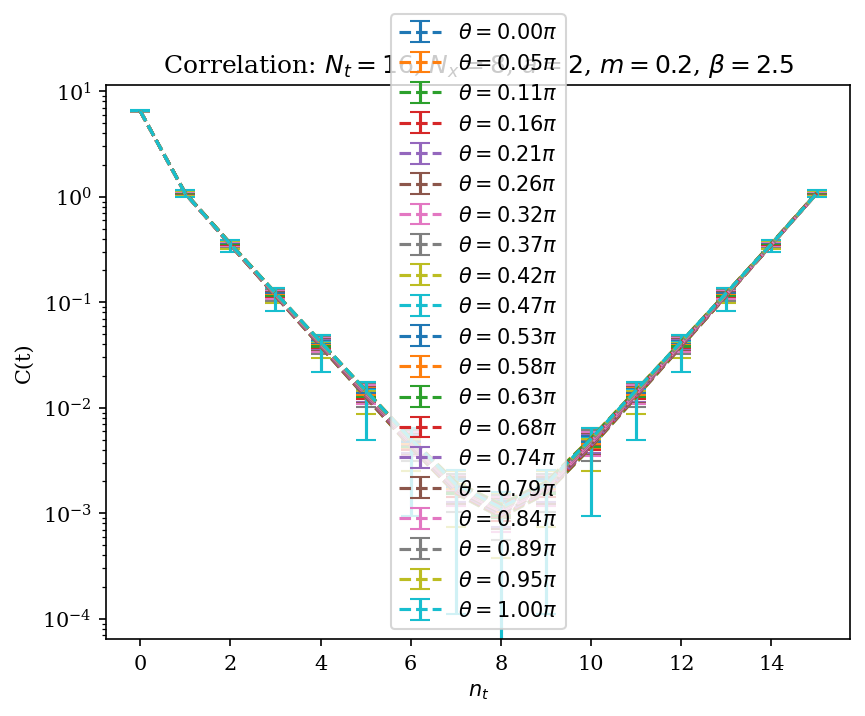

In [19]:
plt.figure(dpi=150)
for i, c in enumerate(correls):
    plt.errorbar(x=np.arange(len(c[0])), y=c[0],yerr=c[1],label=rf"$\theta={(thetas[i]/np.pi):.2f} \pi$",ls="--",capsize=5)
    
plt.semilogy()
plt.legend()
plt.xlabel("$n_t$")
plt.ylabel("C(t)")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$")

Text(0.5, 1.0, '$am$ vs. $\\theta$: $N_t = 16$, $N_x=8$, $a=2$, $m=0.2$, $\\beta=2.5$')

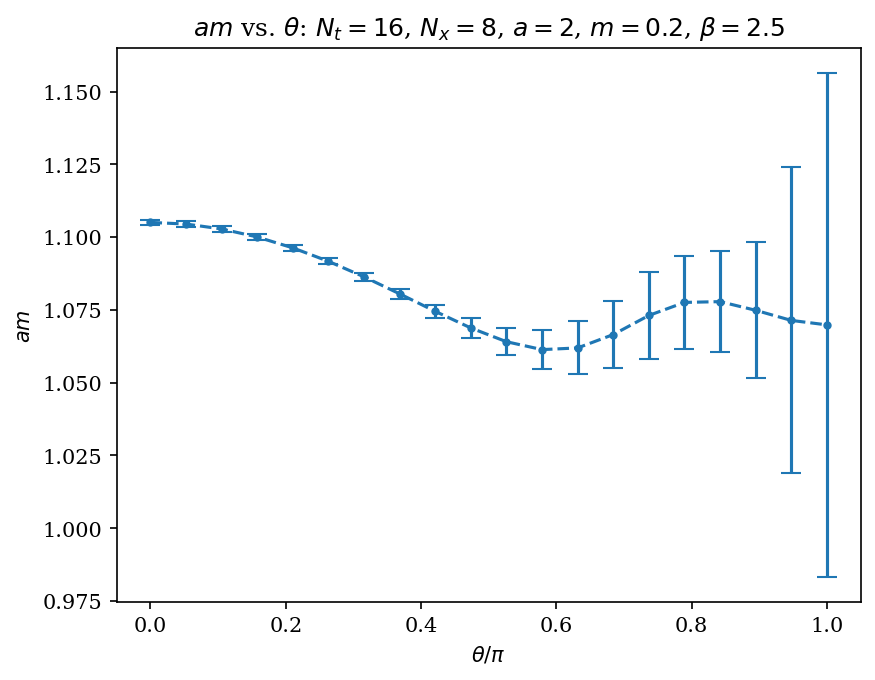

In [20]:
plt.figure(dpi=150)
plt.errorbar(x=thetas/np.pi, y=masses[:,0],yerr=masses[:,1],ls="--",capsize=5,marker=".")

plt.xlabel(r"$\theta/\pi$")
plt.ylabel("$am$")
plt.title(rf"$am$ vs. $\theta$: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$")